In [6]:
import numpy as np
import pandas as pd

df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df['sentiment_encoded'].value_counts()

sentiment_encoded
5    7888
0    7808
1    7697
2    7318
3    6315
Name: count, dtype: int64

In [3]:
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


Split data

In [7]:
from sklearn.model_selection import train_test_split

# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib
# Create a pipeline that first vectorizes the text and then applies the Random Forest classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))  # Random Forest classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

joblib.dump(pipeline, 'random_forest.pkl')

Hyper Parameter Tuning

In [38]:
from sklearn.model_selection import GridSearchCV
import joblib

# Define the parameter grid for GridSearchCV
param_grid = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    pipeline,          # our previously defined pipeline
    param_grid,        # hyperparameters to tune
    cv=5,              # 5-fold cross-validation
    n_jobs=-1,         # use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (GridSearchCV):", grid_search.best_score_)

# Optionally, save the best model (from either search) for future use
# For example, using the grid search best estimator:
joblib.dump(grid_search.best_estimator_, 'random_forest_best_grid.pkl')

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


/opt/homebrew/Caskroom/miniconda/base/envs/TXSA/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters from GridSearchCV: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (GridSearchCV): 0.938656313301823
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'rf__max_depth': None, 'rf__min_samples_split': 8, 'rf__n_estimators': 221, 'tfidf__max_df': 0.9, 'tfidf__min_df': 7, 'tfidf__ngram_range': (1, 1)}
Best cross-validation score (RandomizedSearchCV): 0.9386563133018232


['random_forest_best_random.pkl']

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
import joblib

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],
    'tfidf__min_df': sp_randint(1, 10),
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'rf__n_estimators': sp_randint(100, 500),
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': sp_randint(2, 11)
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,         # number of parameter settings sampled
    cv=5,              # 5-fold cross-validation
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score (RandomizedSearchCV):", random_search.best_score_)

# Or for the randomized search best estimator:
joblib.dump(random_search.best_estimator_, 'random_forest_best_random.pkl')

In [4]:
import joblib

# Load the saved model from file
loaded_model = joblib.load('../models/random_forest_model.pkl')

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, loaded_model.predict(X_test))
print("Accuracy:", accuracy)

Accuracy: 0.9422090197137456


Classification Report

In [27]:
from sklearn.metrics import classification_report

# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1552
           1       0.99      0.99      0.99      1538
           2       0.94      0.88      0.91      1459
           3       0.81      0.90      0.85      1291
           5       0.97      0.96      0.96      1566

    accuracy                           0.94      7406
   macro avg       0.94      0.94      0.94      7406
weighted avg       0.94      0.94      0.94      7406



Confusion Matrix

Confusion Matrix:
[[1515    0    2   33    2]
 [   4 1519    4    8    3]
 [   0    3 1286  165    5]
 [  19    6   64 1158   44]
 [   1    1    7   57 1500]]


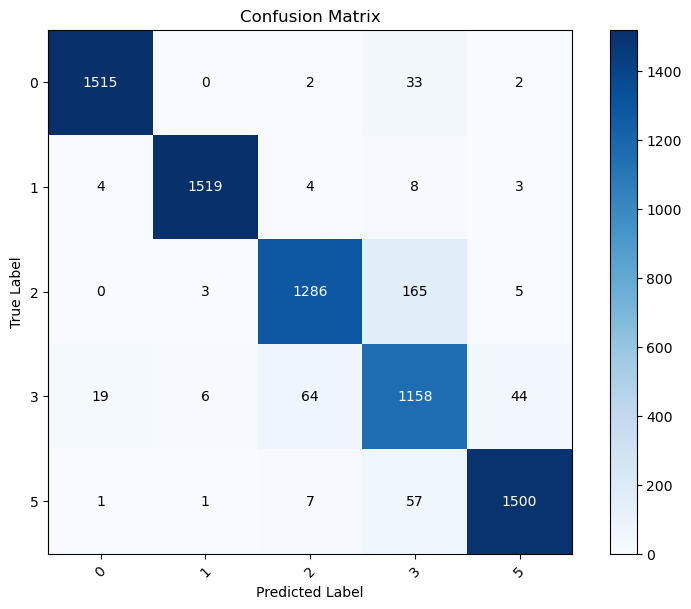

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [ ]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())


Prediction

In [36]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('random_forest.pkl')

# 2. Define a new piece of text to classify
new_text = "I absolutely love this product, it's fantastic!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I absolutely love this product, it's fantastic!
Predicted Sentiment: 3


Feature Importance

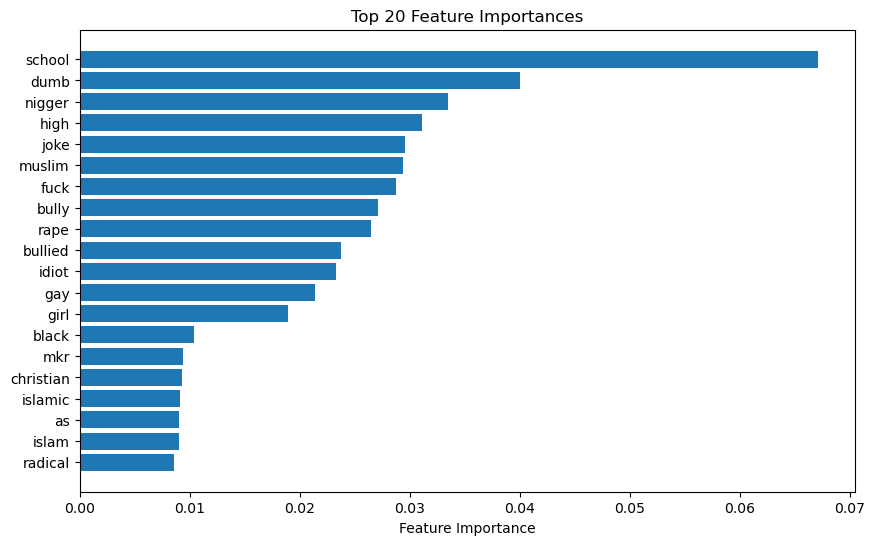

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature names from the TF-IDF vectorizer in the pipeline
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()

# Get feature importances from the Random Forest classifier
importances = pipeline.named_steps['rf'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort the DataFrame by importance and select the top 20 features
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Plot a horizontal bar chart for these top features
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], align='center')
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis so the most important feature is at the top
plt.show()

ROC Curve & AUC: Useful for visualizing the trade-off between the true positive rate and false positive rate (especially for binary classification). For multiclass, you can compute one-vs-rest curves.

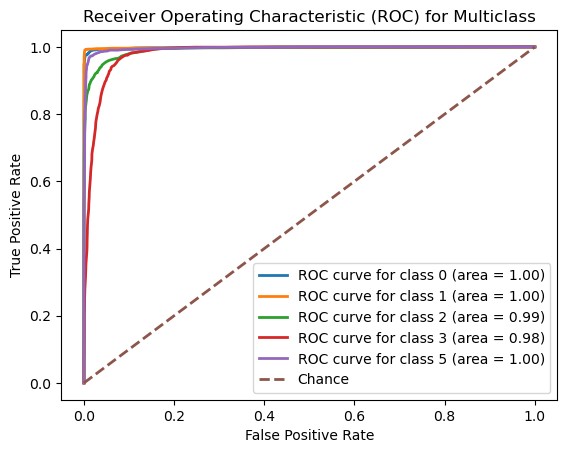

In [8]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assume y_test are the true labels and pipeline.predict_proba(X_test) returns
# probability estimates for each class.
y_score = pipeline.predict_proba(X_test)
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize the output for one-vs-rest ROC computation
y_test_bin = label_binarize(y_test, classes=classes)

# Initialize dictionaries to store ROC metrics for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label='ROC curve for class %d (area = %0.2f)' % (classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multiclass')
plt.legend(loc="lower right")
plt.show()

Precision-Recall Curve: Ideal for imbalanced classes where positive class performance is more critical.

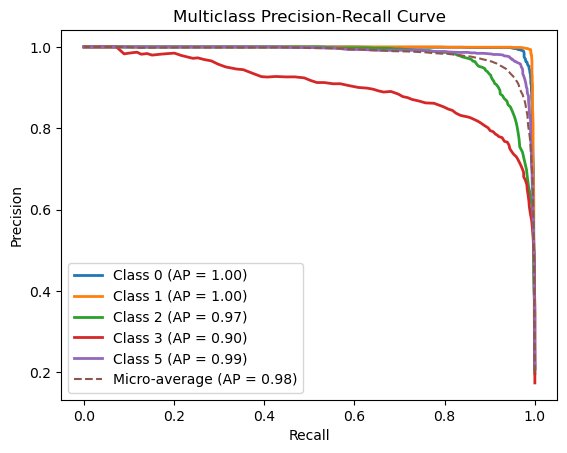

In [10]:
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Get probability estimates for all classes
y_score = pipeline.predict_proba(X_test)

# Identify unique classes and binarize the true labels for one-vs-rest comparison
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Initialize dictionaries to hold precision, recall and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

# Optionally, compute a micro-average across all classes
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
average_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Plot Precision-Recall curve for each class
plt.figure()
for i in range(n_classes):
    plt.plot(recall[i], precision[i], lw=2,
             label='Class %d (AP = %0.2f)' % (classes[i], average_precision[i]))

# Plot the micro-average curve
plt.plot(recall["micro"], precision["micro"], linestyle='--',
         label='Micro-average (AP = %0.2f)' % average_precision["micro"])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass Precision-Recall Curve')
plt.legend(loc="best")
plt.show()

Stratified K-Fold Cross Validation: Ensures that each fold has approximately the same class distribution as the whole dataset, which is particularly useful for imbalanced classes.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)
skf_scores = cross_val_score(pipeline, X, y, cv=skf)
print("Stratified K-Fold CV Scores:", skf_scores)
print("Mean Stratified K-Fold CV Score:", skf_scores.mean())

Stratified K-Fold CV Scores: [0.94747502 0.93720459 0.93841999 0.93787981 0.93774477]
Mean Stratified K-Fold CV Score: 0.9397448352459081
